# CREACIÓN DE UNA RED NEURONAL PARA CLASIFICAR LA ESPECIE DE PINGUINO

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset
df = sns.load_dataset("penguins")
df = df.dropna()  # Eliminar filas con valores nulos
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# GRAFICAMOS LA DISTRIBUCIÓN DE LAS SPECIES

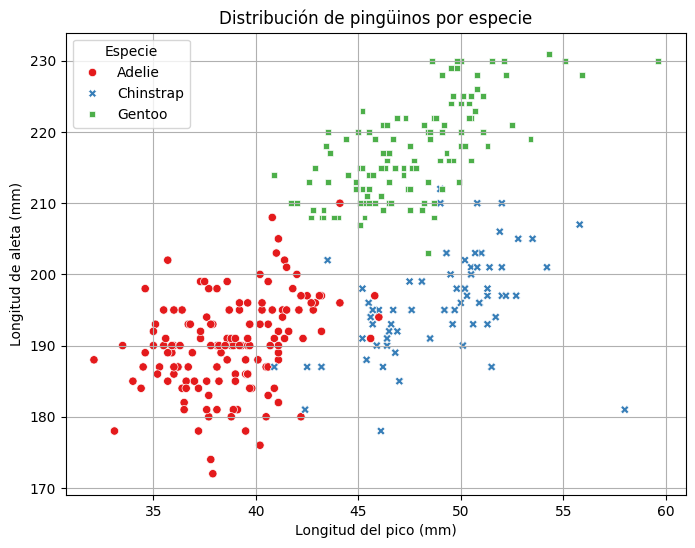

In [2]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="species",
    palette="Set1"
)
plt.title("Distribución de pingüinos por especie")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Longitud de aleta (mm)")
plt.grid(True)
plt.legend(title="Especie")
plt.show()

# CREACIÓN DE MODELO DE RED NEURONAL

## PASO 1 - IMPORTAMOS LIBRERIAS NECESARIAS

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## PASO 2 - IDENTIFICAR VARIABLE X Y Y

In [4]:
X = df[['bill_length_mm', 'flipper_length_mm']]
y = df['species']

## PASO 3 - CODIFICAR VARIABLES CATEGORICAS

In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Ej: Adelie=0, Chinstrap=1, Gentoo=2
y_onehot = tf.keras.utils.to_categorical(y_encoded)

## PASO 4 - ESCALAMIENTO DE DATOS

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PASO 5 - DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42)

## PASO 6 - CREAMOS UNA RED NEURONAL NEURONAL SECUENCIAL

In [12]:
model = Sequential(
    [
        Dense(8,activation='relu',input_shape=(2,)),
        Dense(6,activation='relu'),
        Dense(3,activation='softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## PASO 7 - COMPILAMOS LA RED

In [16]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# PASO 8 - ENTRENAMOS LA RED NEURONAL

In [17]:
model.fit(X_train,
          y_train,
          epochs=20,
          batch_size=8,
          validation_split=0.2)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1637 - loss: 1.2760 - val_accuracy: 0.1296 - val_loss: 1.2266
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1641 - loss: 1.1802 - val_accuracy: 0.0926 - val_loss: 1.1395
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2423 - loss: 1.0998 - val_accuracy: 0.1667 - val_loss: 1.0676
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4095 - loss: 1.0314 - val_accuracy: 0.5370 - val_loss: 0.9999
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6733 - loss: 0.9789 - val_accuracy: 0.7407 - val_loss: 0.9310
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8039 - loss: 0.9030 - val_accuracy: 0.7778 - val_loss: 0.8607
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8004 - loss: 0.8382 - val_accuracy: 0.7778 - val_loss: 0.7913
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7480 - loss: 0.7869 - val_accuracy: 0.7778 - val_loss

## PASO 9 - EVALUAMOS LA RED NEURONAL

In [18]:
loss,accuracy = model.evaluate(X_test,y_test)
print(f"Accuracy en test: {accuracy:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9197 - loss: 0.3052
Accuracy en test: 0.93


## PASO 10 - HACEMOS PREDICCIONES

In [19]:
predictions = model.predict(X_test)
print("Predicciones:", le.inverse_transform(np.argmax(predictions, axis=1)))
print("Reales:", le.inverse_transform(np.argmax(y_test[:5], axis=1)))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicciones: ['Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo'
 'Chinstrap' 'Chinstrap' 'Chinstrap' 'Adelie' 'Adelie' 'Gentoo' 'Adelie'
 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie'
 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo'
 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Adelie' 'Chinstrap'
 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Adelie'
 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie'
 'Chinstrap' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie'
 'Gentoo' 'Adelie']
Reales: ['Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie']


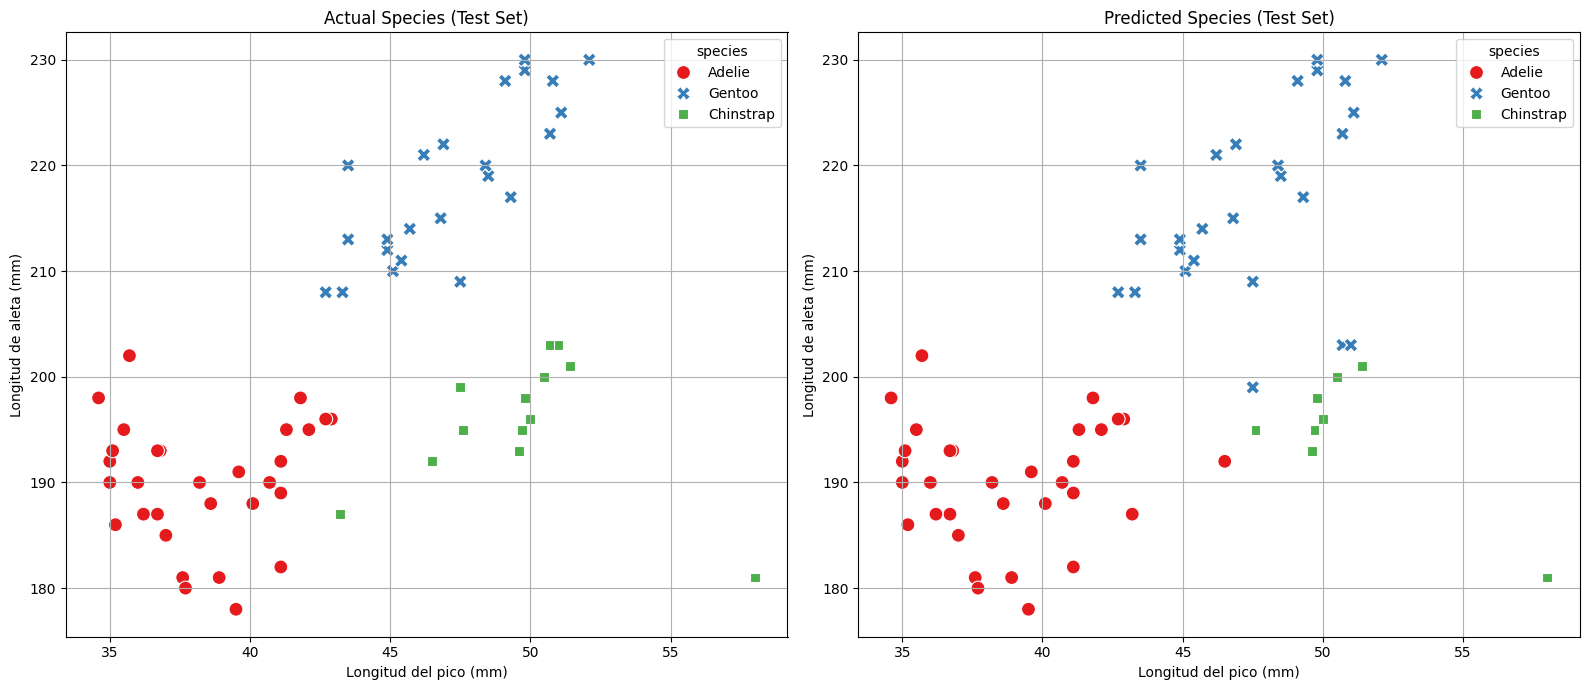

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inverse transform X_test to get original scale values for plotting
X_test_original = scaler.inverse_transform(X_test)

# Convert one-hot encoded y_test and predictions back to original species labels
y_test_labels = le.inverse_transform(np.argmax(y_test, axis=1))
y_pred_labels = le.inverse_transform(np.argmax(predictions, axis=1))

# Create a DataFrame for plotting
plot_df_actual = pd.DataFrame(X_test_original, columns=['bill_length_mm', 'flipper_length_mm'])
plot_df_actual['species'] = y_test_labels

plot_df_predicted = pd.DataFrame(X_test_original, columns=['bill_length_mm', 'flipper_length_mm'])
plot_df_predicted['species'] = y_pred_labels

# Create subplots
plt.figure(figsize=(16, 7))

# Plot actual values
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=plot_df_actual,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="species",
    palette="Set1",
    s=100
)
plt.title("Actual Species (Test Set)")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Longitud de aleta (mm)")
plt.grid(True)

# Plot predicted values
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=plot_df_predicted,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="species",
    palette="Set1",
    s=100
)
plt.title("Predicted Species (Test Set)")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Longitud de aleta (mm)")
plt.grid(True)

plt.tight_layout()
plt.show()